# Duomenu aibes aprasymas, transformacijos

#### Importuojame paketus, paruošiame grafikų stilių

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd

import seaborn as sns
import matplotlib.pyplot as plt
import contextily as cx

plt.style.use('bmh')
plt.rcParams['axes.facecolor'] = 'white'

## Duomenų importavimas

Visi failai pasiekiami OneDrive.

*Tolimesnio kodo paleidimas reikalauja daug RAM. Leisti kodą po "1 laboratorinio darbo kopija". Failas data.csv įkeltas į OneDrive.*

In [2]:
rng = np.random.default_rng(1)

In [ ]:
SHIP_TYPE = ['Cargo', 'Tanker', 'Passenger', 'Pilot', 'Fishing']

def filter_data_set(df):
    df_filtered = df[
        df['Latitude'].between(54, 56) &
        df['Longitude'].between(12, 17) &
        (df['Navigational status'] == 'Under way using engine') &
        (df['Type of mobile'] == 'Class A') &
        df['Ship type'].isin( SHIP_TYPE )
    ].copy(deep=True)

    return df_filtered

In [4]:
df_parts = []
file_names = [
    'aisdk-2026-02-01.csv',
    'aisdk-2026-02-02.csv',
    'aisdk-2026-02-03.csv',
    'aisdk-2026-02-04.csv',
    'aisdk-2026-02-05.csv',
]

for file_name in file_names:

    df_chunks = pd.read_csv(file_name, chunksize=2**20)

    for df_chunk in df_chunks:
        df_filtered = filter_data_set(df_chunk)
        df_parts.append(df_filtered)
        del df_chunk

    del df_chunks

In [5]:
df = pd.concat(df_parts, axis=0)

In [6]:
df.groupby('Ship type')['MMSI'].nunique()

Ship type
Cargo        479
Fishing       18
Passenger     46
Pilot         13
Tanker       175
Name: MMSI, dtype: int64

In [9]:
dfs = []

for ship_type in df['Ship type'].unique():
    type_mask = df['Ship type'] == ship_type
    type_mmsi = rng.choice(
        df[type_mask]['MMSI'].unique(),
        size=13,
        replace=False
    )

    dfs.append( df[df['MMSI'].isin(type_mmsi)].copy() )

In [10]:
df = pd.concat(dfs, axis=0)
df.to_csv('data.csv')

## Leisti nuo čia

In [11]:
df = pd.read_csv('data.csv', engine='pyarrow')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1269195 entries, 0 to 1269194
Data columns (total 27 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0                                   1269195 non-null  int64  
 1   # Timestamp                     1269195 non-null  object 
 2   Type of mobile                  1269195 non-null  object 
 3   MMSI                            1269195 non-null  int64  
 4   Latitude                        1269195 non-null  float64
 5   Longitude                       1269195 non-null  float64
 6   Navigational status             1269195 non-null  object 
 7   ROT                             876376 non-null   float64
 8   SOG                             1269155 non-null  float64
 9   COG                             1269155 non-null  float64
 10  Heading                         1201871 non-null  float64
 11  IMO                             1269195 non-null  object 
 12  

# 1 laboratorinio darbo kopija

In [12]:
df['Ship type'].value_counts()

Ship type
Pilot        532179
Passenger    337463
Fishing      157373
Cargo        154456
Tanker        87724
Name: count, dtype: int64

### Ištiriam praleistas reikšmes, skirtumus tarp stebėjimų

Čia mūsų siekis bus dvejopas:
1. Susitvarkyti su praleistomis reikšmėmis;
2. Išplėsti laiko eilutes į lygiai vienos minutės intervalus, t. y, padaryti taip, kad tarp vieno laivo AIS signalų visą laiką būtų vienos minutės skirtumas.

In [13]:
numerical = ['ROT', 'SOG', 'COG', 'Heading']
df[numerical].isnull().sum()

ROT        392819
SOG            40
COG            40
Heading     67324
dtype: int64

In [14]:
df_filtered = df

In [15]:
df_filtered[numerical].isnull().agg(['sum', 'mean'])

,ROT,SOG,COG,Heading
sum,392819.000000,40.000000,40.000000,67324.000000
mean,0.309502,0.000032,0.000032,0.053045


#### Praleistų reikšmių skaičius/dalis kiekvienam kintamajam

In [16]:
output = []

for ship_type, type_data in df_filtered.groupby('Ship type'):

    for col in numerical:
        output.append({
            'Laivo tipas': ship_type,
            'Kintamasis': col,
            'Praleistų reikšmių dalis, %': type_data[col].isnull().mean() * 100
        })

pd.DataFrame(output).pivot(columns=['Kintamasis'], index=['Laivo tipas'])

Praleistų reikšmių dalis, %                                
Kintamasis                          COG    Heading        ROT       SOG
Laivo tipas                                                            
Cargo                          0.000000   0.000000  37.766095  0.000000
Fishing                        0.002542   3.484715  30.212934  0.002542
Passenger                      0.000000   1.748636  11.545562  0.000000
Pilot                          0.006577  10.511313  46.002191  0.006577
Tanker                         0.001140   0.000000   3.606767  0.001140

> Passenger turi 23 % praleistų reikšmių ROT. ROT - dažniausiai nulis, taigi jam taikysime 0 įrašymą

In [17]:
for mmsi, mmsi_data in df_filtered.groupby('MMSI'):

    if any( df_filtered[numerical].isnull().mean() >= 1 ):
        print(mmsi)

> Užpildome

In [18]:
df.loc[ df['ROT'].isnull(), 'ROT' ] = 0

> Toliau reikia ištirti ar laiko skirtumas tarp stebėjimų neviršija 2 valandų (literatūroje taikyta riba)

In [19]:
from datetime import timedelta

In [20]:
df_filtered['# Timestamp'] = pd.to_datetime( df_filtered['# Timestamp'], dayfirst=True )
df_filtered['day'] = df_filtered['# Timestamp'].dt.normalize()

In [21]:
df = []
for mmsi, mmsi_data in df_filtered.groupby(['MMSI', 'day']):

    mmsi_data = mmsi_data\
        .sort_values('# Timestamp')\
        .reset_index(drop=True)

    time_diff = mmsi_data['# Timestamp'].diff(1)
    max_time_diff = time_diff.max()

    if max_time_diff >= timedelta(hours=2):
        first_gap = mmsi_data[ time_diff >= timedelta(hours=2) ].index[0]
        mmsi_data_wo_gap = mmsi_data.iloc[:first_gap, :]
        df.append(mmsi_data_wo_gap)

    else:
        df.append(mmsi_data)

In [22]:
df_filtered = pd.concat(df).reset_index(drop=True)

## isskirtys

In [23]:

numerical_cols = ["ROT", "SOG", "COG", "Heading"]
for col in numerical_cols:
    df_col = df_filtered[col]
    
    Q1 = df_col.quantile(0.25)
    Q3 = df_col.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df_filtered[(df_filtered[col] < lower) | (df_filtered[col] > upper)]
    
    print(f"\n{col}")
    print("Lower:", round(lower, 2))
    print("Upper:", round(upper, 2))
    print("Min:", round(df_col.min(), 2))
    print("Max:", round(df_col.max(), 2))
    print("Outliers:", len(outliers))



ROT
Lower: 0.0
Upper: 0.0
Min: -420.0
Max: 708.7
Outliers: 161006

SOG
Lower: -17.85
Upper: 29.75
Min: 0.0
Max: 74.5
Outliers: 4

COG
Lower: -170.1
Upper: 523.5
Min: 0.0
Max: 359.9
Outliers: 0

Heading
Lower: -209.0
Upper: 559.0
Min: 0.0
Max: 359.0
Outliers: 0


In [24]:
numerical_cols = ["ROT", "SOG"]

for ship_type, group in df_filtered.groupby("Ship type"):
    
    print(f"\n===== Ship type: {ship_type} =====")
    
    for col in numerical_cols:
        df_col = group[col].dropna()
        
        Q1 = df_col.quantile(0.25)
        Q3 = df_col.quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = group[(group[col] < lower) | (group[col] > upper)]
        
        print(f"\n{col}")
        print("Q1:", round(Q1, 2))
        print("Q3:", round(Q3, 2))
        print("Lower:", round(lower, 2))
        print("Upper:", round(upper, 2))
        print("Min:", round(df_col.min(), 2))
        print("Max:", round(df_col.max(), 2))
        print("Outliers:", len(outliers))



===== Ship type: Cargo =====

ROT
Q1: 0.0
Q3: 0.0
Lower: 0.0
Upper: 0.0
Min: -120.7
Max: 116.1
Outliers: 30136

SOG
Q1: 7.8
Q3: 11.1
Lower: 2.85
Upper: 16.05
Min: 0.0
Max: 19.7
Outliers: 28959

===== Ship type: Fishing =====

ROT
Q1: 0.0
Q3: 0.0
Lower: 0.0
Upper: 0.0
Min: 0.0
Max: 0.0
Outliers: 0

SOG
Q1: 0.0
Q3: 11.5
Lower: -17.25
Upper: 28.75
Min: 0.0
Max: 74.5
Outliers: 4

===== Ship type: Passenger =====

ROT
Q1: 0.0
Q3: 0.0
Lower: 0.0
Upper: 0.0
Min: -61.1
Max: 32.5
Outliers: 64687

SOG
Q1: 0.0
Q3: 16.8
Lower: -25.2
Upper: 42.0
Min: 0.0
Max: 22.8
Outliers: 0

===== Ship type: Pilot =====

ROT
Q1: 0.0
Q3: 0.0
Lower: 0.0
Upper: 0.0
Min: -420.0
Max: 708.7
Outliers: 1460

SOG
Q1: 0.0
Q3: 6.9
Lower: -10.35
Upper: 17.25
Min: 0.0
Max: 29.0
Outliers: 37167

===== Ship type: Tanker =====

ROT
Q1: -1.6
Q3: 2.2
Lower: -7.3
Upper: 7.9
Min: -86.4
Max: 82.5
Outliers: 17749

SOG
Q1: 9.8
Q3: 12.8
Lower: 5.3
Upper: 17.3
Min: 0.0
Max: 15.2
Outliers: 456


Taikant IQR metodą nustatyta, kad kintamasis ROT turi labai daug išskirčių. Tačiau tai paaiškinama tuo, kad didžioji dalis stebėjimų turi reikšmę 0 (laivas juda tiesiai), todėl kvartilių intervalas lygus nuliui ir visi nenuliniai stebėjimai klasifikuojami kaip išskirtys. Todėl pasirinkome išskirčių nešalinti.


# isimt ROT = 0 ir su boxplotu patikrint isskirtis

In [25]:
df_isskirciu = df_filtered.copy()
df_isskirciu = df_isskirciu[df_isskirciu["ROT"] != 0]

In [26]:

numerical_cols = ["ROT", "SOG", "COG", "Heading"]
for col in numerical_cols:
    df_col = df_isskirciu[col]
    
    Q1 = df_col.quantile(0.25)
    Q3 = df_col.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df_isskirciu[(df_isskirciu[col] < lower) | (df_isskirciu[col] > upper)]
    
    print(f"\n{col}")
    print("Lower:", round(lower, 2))
    print("Upper:", round(upper, 2))
    print("Min:", round(df_col.min(), 2))
    print("Max:", round(df_col.max(), 2))
    print("Outliers:", len(outliers))



ROT
Lower: -14.4
Upper: 14.4
Min: -420.0
Max: 708.7
Outliers: 23385

SOG
Lower: 1.0
Upper: 25.8
Min: 0.0
Max: 23.1
Outliers: 551

COG
Lower: -215.3
Upper: 520.7
Min: 0.0
Max: 359.9
Outliers: 0

Heading
Lower: -208.0
Upper: 512.0
Min: 0.0
Max: 359.0
Outliers: 0


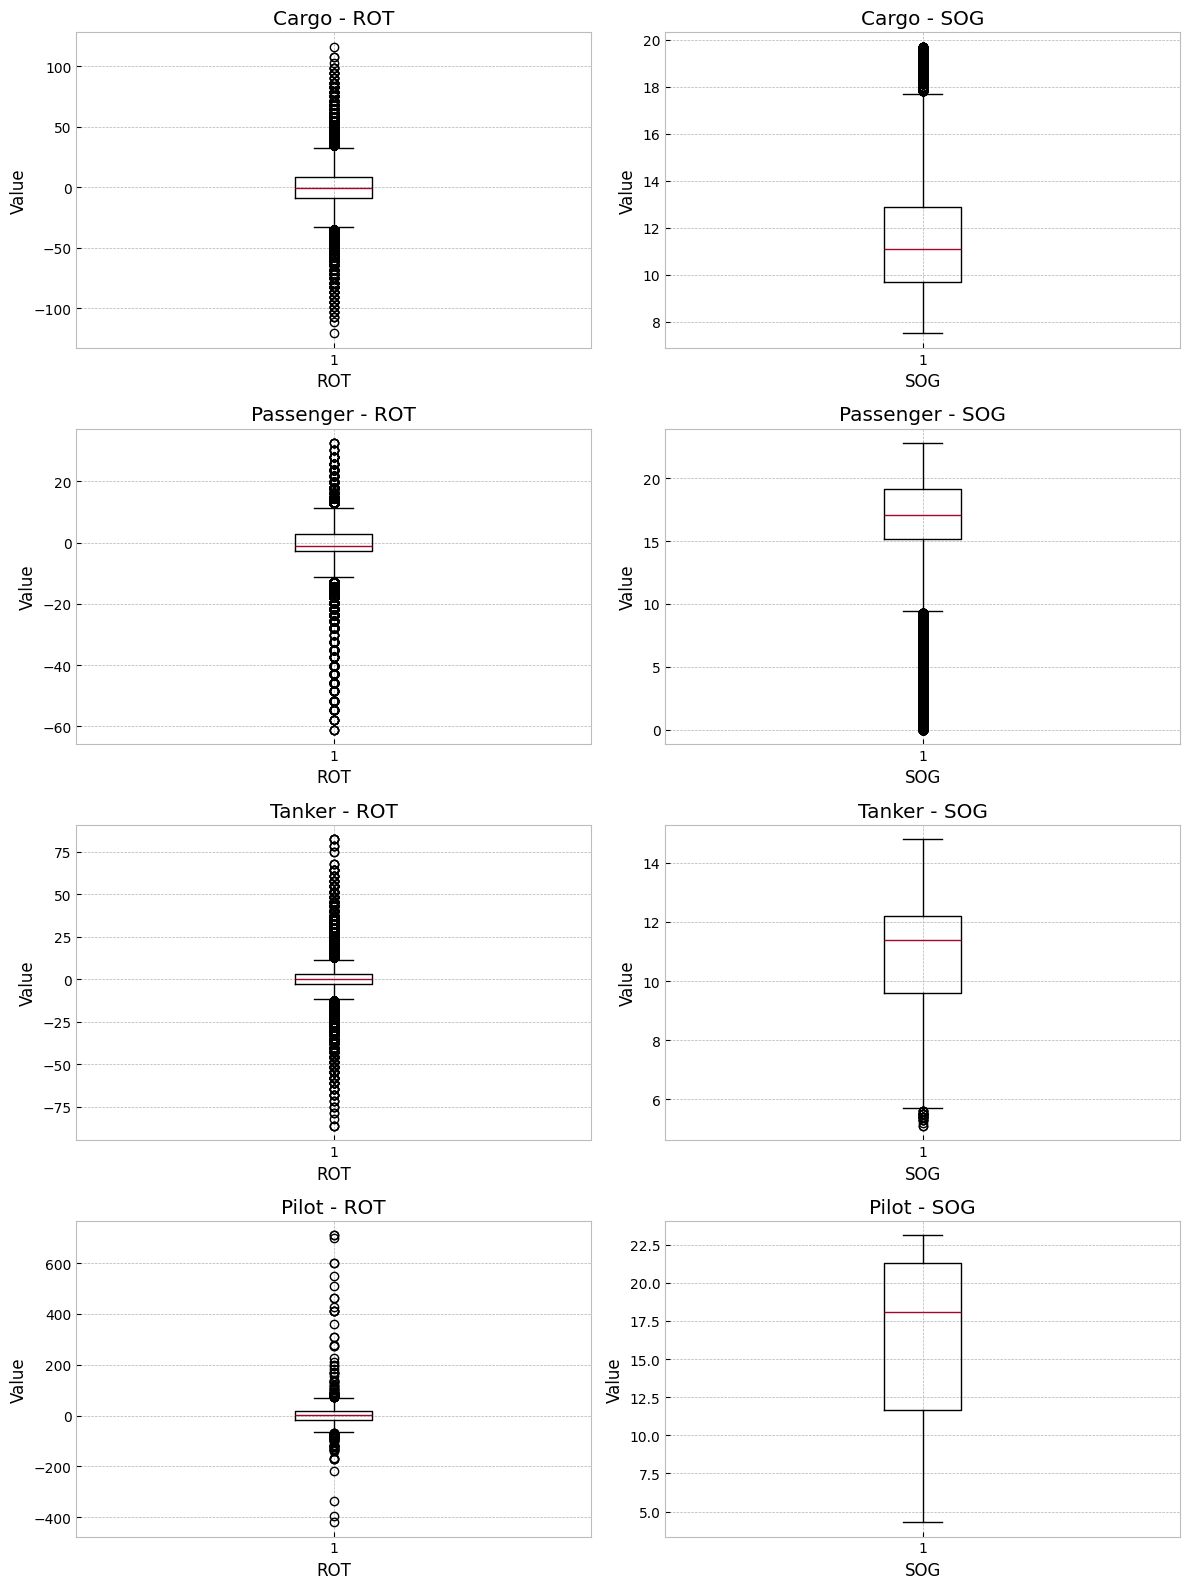

In [27]:
import matplotlib.pyplot as plt
import math

numerical_cols = ["ROT", "SOG"]

ship_types = df_isskirciu["Ship type"].dropna().unique()
n_ship_types = len(ship_types)
n_cols = len(numerical_cols)

# Grid dimensijos
rows = n_ship_types
cols = n_cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))

# Jei tik vienas ship type arba vienas column – sutvarkome indexing
if rows == 1:
    axes = [axes]
if cols == 1:
    axes = [[ax] for ax in axes]

for i, ship_type in enumerate(ship_types):
    group = df_isskirciu[df_isskirciu["Ship type"] == ship_type]
    
    for j, col in enumerate(numerical_cols):
        ax = axes[i][j]
        
        ax.boxplot(group[col].dropna())
        ax.set_title(f"{ship_type} - {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


### Praleistų reikšmių užpildymas: kubinė interpoliacija

In [28]:
dfs = []
tarpai = []
praleistu_count = 0

for mmsi, mmsi_df in df_filtered.groupby('MMSI'):

    tarpai.extend( mmsi_df['# Timestamp'].diff(1).dropna().to_list() )
    
    # Atliekam transformacijq
    mmsi_df['Heading'] = mmsi_df['Heading']\
        .apply(lambda x: 360 - x if x > 180.0 else x)
    mmsi_df['COG'] = mmsi_df['COG']\
        .apply(lambda x: 360 - x if x > 180.0 else x)

    # Išplėčiame ir interpoliuojame
    output_df = mmsi_df.set_index('# Timestamp')\
        [['Latitude', 'Longitude', 'ROT', 'SOG', 'COG', 'Heading']]\
        .resample('60s')\
        .median()

    if output_df.shape[0] <= 2:
        continue

    praleistu_count += output_df.isnull().sum()
    
    output_df = output_df\
        .interpolate('pchip')\
        .reset_index()

    # Ištaisome klaidas
    output_df['Heading'] = np.clip(output_df['Heading'], 0, 360)
    output_df['COG'] = np.clip(output_df['COG'], 0, 360)
    output_df['Latitude'] = np.clip(output_df['Latitude'], 54.0, 56.0)
    output_df['Longitude'] = np.clip(output_df['Longitude'], 12.0, 17.0)

    # Apskaičiuojame komponentes
    output_df['delta_lat'] = output_df['Latitude'].diff(1).abs()
    output_df['delta_lon'] = output_df['Longitude'].diff(1).abs()

    # Priskiriame MMSI ir laivo tipo reikšmes, nes šiuo metu jų nėra output_df
    output_df['MMSI'] = mmsi
    output_df['Ship type'] = mmsi_df['Ship type'].values[0]

    # Surenkame
    dfs.append(output_df)

data = pd.concat(dfs, ignore_index=True).dropna()

In [29]:
tarpai = np.array(tarpai)
tarpai = tarpai[ tarpai != 0 ]

np.quantile(tarpai, [0.05, 0.95])

array([Timedelta('0 days 00:00:00'), Timedelta('0 days 00:00:20')],
      dtype=object)

> Tarpai tarp AIS stebėjimų yra 0 - 20 sekundžių

In [30]:
praleistu_count / data.shape[0]

Latitude     0.424409
Longitude    0.424409
ROT          0.424409
SOG          0.424409
COG          0.424409
Heading      0.485012
dtype: float64

> Interpoliuota: 5-7 % praleistų reikšmių

In [31]:
print('Stebėjimų skaičius', data.shape[0])
print('Laivų skaičius', data['MMSI'].nunique())

Stebėjimų skaičius 195719
Laivų skaičius 61


## Rinkinio peržiūra

In [32]:
data = data.sort_values(['MMSI', '# Timestamp'])

In [33]:
data.head()

,# Timestamp,Latitude,Longitude,ROT,SOG,COG,Heading,delta_lat,delta_lon,MMSI,Ship type
1,2026-02-01 00:01:00,55.194822,13.528742,0.0,5.75,96.8,100.0,0.000175,0.002543,210387000,Cargo
2,2026-02-01 00:02:00,55.194603,13.532090,0.0,6.40,96.7,99.0,0.000219,0.003348,210387000,Cargo
3,2026-02-01 00:03:00,55.194377,13.535200,0.0,6.40,99.6,100.0,0.000226,0.003110,210387000,Cargo
4,2026-02-01 00:04:00,55.194107,13.538452,0.0,6.40,97.4,99.0,0.000270,0.003252,210387000,Cargo
5,2026-02-01 00:05:00,55.193930,13.541007,0.0,5.40,97.1,100.0,0.000177,0.002555,210387000,Cargo


In [34]:

import pandas as pd

numeric_cols = data[numerical]

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
min_vals = numeric_cols.min()
max_vals = numeric_cols.max()

desc_stats = pd.DataFrame({
    'Minimumas': min_vals,
    '$Q_1$': Q1,
    'Vidurkis': numeric_cols.mean(),
    '$Q_3$': Q3,
    '$IQR$': Q3 - Q1,
    'Maksimumas': max_vals,
    'Standartinis nuokrypis': numeric_cols.std()
})

pd.options.display.float_format = '{:.3f}'.format
print(desc_stats.to_latex(float_format='{:.3f}'.format))


\begin{tabular}{lrrrrrrr}
\toprule
 & Minimumas & $Q_1$ & Vidurkis & $Q_3$ & $IQR$ & Maksimumas & Standartinis nuokrypis \\
\midrule
ROT & -115.200 & 0.000 & 0.028 & 0.000 & 0.000 & 171.600 & 3.947 \\
SOG & 0.000 & 0.000 & 7.599 & 12.776 & 12.776 & 28.800 & 7.038 \\
COG & 0.000 & 54.905 & 88.109 & 126.639 & 71.734 & 180.000 & 48.004 \\
Heading & 0.000 & 45.000 & 83.447 & 121.540 & 76.540 & 180.000 & 46.332 \\
\bottomrule
\end{tabular}



In [35]:
data['ROT'] = np.arcsinh(data['ROT'])

# kampų transformacija
heading_rad = np.deg2rad(data['Heading'])
cog_rad = np.deg2rad(data['COG'])

data['Heading_sin'] = np.sin(heading_rad)
data['Heading_cos'] = np.cos(heading_rad)

data['COG_sin'] = np.sin(cog_rad)
data['COG_cos'] = np.cos(cog_rad)

# pašaliname originalius kampus
# data = data.drop(columns=['Heading', 'COG'])

In [36]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
standscaler = StandardScaler()
minmaxscaler = MinMaxScaler()
numerical = [
    'Latitude',
    'Longitude',
    'ROT',
    'SOG',
    'Heading_sin',
    'Heading_cos',
    'COG_sin',
    'COG_cos',
    'delta_lon',
    'delta_lat'
]
standscaler.fit(data[numerical])
minmaxscaler.fit(data[numerical])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [37]:
standdata = data.copy()
standdata[numerical] = standscaler.transform(data[numerical])

In [38]:
standdata[numerical].describe()

,Latitude,Longitude,ROT,SOG,Heading_sin,Heading_cos,COG_sin,COG_cos,delta_lon,delta_lat
count,195719.000,195719.000,195719.000,195719.000,195719.000,195719.000,195719.000,195719.000,195719.000,195719.000
mean,0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.502,-1.379,-5.037,-1.080,-2.394,-1.687,-2.282,-1.540,-0.565,-0.535
25%,-0.439,-0.834,0.005,-1.080,-0.640,-0.945,-0.833,-0.929,-0.563,-0.532
50%,0.136,-0.395,0.005,0.041,0.396,0.140,0.400,-0.006,-0.552,-0.511
75%,0.655,0.828,0.005,0.736,0.863,0.970,0.860,0.847,0.141,-0.029
max,1.421,2.246,5.416,3.012,1.012,1.426,1.035,1.491,16.635,9.393


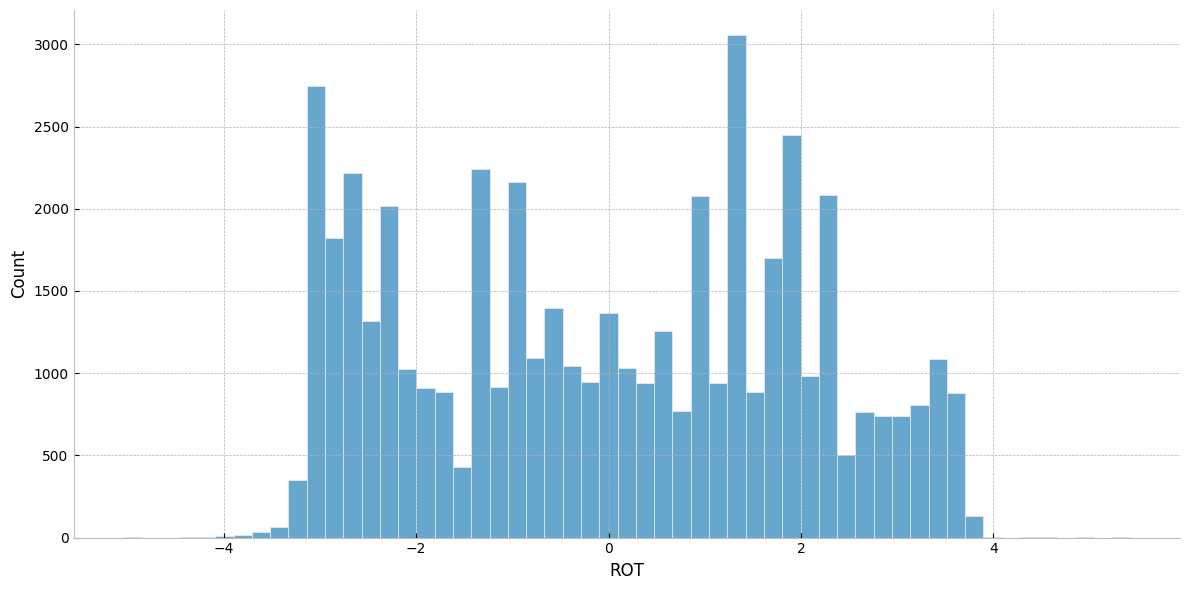

In [39]:
sns.displot(standdata[standdata.ROT != standdata.ROT.median()]['ROT'], height=6, aspect=2)

<Axes: ylabel='ROT'>

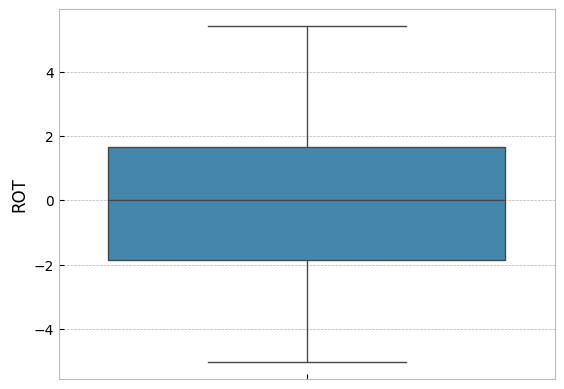

In [40]:
sns.boxplot(standdata[standdata.ROT != standdata.ROT.median()]['ROT'])

In [41]:
data[numerical] = minmaxscaler.transform(data[numerical])

In [42]:
data[numerical].describe()

,Latitude,Longitude,ROT,SOG,Heading_sin,Heading_cos,COG_sin,COG_cos,delta_lon,delta_lat
count,195719.000,195719.000,195719.000,195719.000,195719.000,195719.000,195719.000,195719.000,195719.000,195719.000
mean,0.638,0.380,0.482,0.264,0.703,0.542,0.688,0.508,0.033,0.054
std,0.255,0.276,0.096,0.244,0.294,0.321,0.302,0.330,0.058,0.101
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.526,0.150,0.482,0.000,0.515,0.238,0.437,0.202,0.000,0.000
50%,0.672,0.272,0.482,0.274,0.819,0.587,0.809,0.506,0.001,0.002
75%,0.805,0.609,0.482,0.444,0.956,0.854,0.947,0.787,0.041,0.051
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


### Koreliacijos

In [43]:
corr = data[numerical]\
    .select_dtypes(include=['float64'])\
    .corr(method='spearman')

In [44]:
corr

,Latitude,Longitude,ROT,SOG,Heading_sin,Heading_cos,COG_sin,COG_cos,delta_lon,delta_lat
Latitude,1.000,0.158,0.030,-0.112,-0.002,-0.050,-0.016,-0.088,-0.169,-0.329
Longitude,0.158,1.000,-0.108,-0.072,0.250,0.118,0.190,0.105,0.097,-0.061
ROT,0.030,-0.108,1.000,-0.058,-0.071,-0.016,-0.133,-0.095,0.011,0.013
SOG,-0.112,-0.072,-0.058,1.000,0.247,-0.291,0.277,-0.114,0.475,0.472
Heading_sin,-0.002,0.250,-0.071,0.247,1.000,-0.189,0.558,-0.038,0.095,-0.032
Heading_cos,-0.050,0.118,-0.016,-0.291,-0.189,1.000,-0.088,0.616,-0.204,-0.130
COG_sin,-0.016,0.190,-0.133,0.277,0.558,-0.088,1.000,-0.072,0.118,0.001
COG_cos,-0.088,0.105,-0.095,-0.114,-0.038,0.616,-0.072,1.000,-0.052,-0.078
delta_lon,-0.169,0.097,0.011,0.475,0.095,-0.204,0.118,-0.052,1.000,0.773
delta_lat,-0.329,-0.061,0.013,0.472,-0.032,-0.130,0.001,-0.078,0.773,1.000


# paziureti koreliacijas pagal laivu tipus

## Aprasomoji statistika, palyginimoji analizė

### Aprasomoji statistika

In [45]:
import pandas as pd

numeric_cols = data[numerical]

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
min_vals = numeric_cols.min()
max_vals = numeric_cols.max()

desc_stats = pd.DataFrame({
    'min': min_vals,
    'Q1': Q1,
    'median': numeric_cols.median(),
    'mean': numeric_cols.mean(),
    'Q3': Q3,
    'IQR': Q3 - Q1,
    'max': max_vals,
    'range': max_vals - min_vals,
    'variance': numeric_cols.var(),
    'std_dev': numeric_cols.std()
})

pd.options.display.float_format = '{:.3f}'.format
print(desc_stats)


              min    Q1  median  mean    Q3   IQR   max  range  variance  \
Latitude    0.000 0.526   0.672 0.638 0.805 0.279 1.000  1.000     0.065   
Longitude   0.000 0.150   0.272 0.380 0.609 0.459 1.000  1.000     0.076   
ROT         0.000 0.482   0.482 0.482 0.482 0.000 1.000  1.000     0.009   
SOG         0.000 0.000   0.274 0.264 0.444 0.444 1.000  1.000     0.060   
Heading_sin 0.000 0.515   0.819 0.703 0.956 0.441 1.000  1.000     0.086   
Heading_cos 0.000 0.238   0.587 0.542 0.854 0.615 1.000  1.000     0.103   
COG_sin     0.000 0.437   0.809 0.688 0.947 0.511 1.000  1.000     0.091   
COG_cos     0.000 0.202   0.506 0.508 0.787 0.586 1.000  1.000     0.109   
delta_lon   0.000 0.000   0.001 0.033 0.041 0.041 1.000  1.000     0.003   
delta_lat   0.000 0.000   0.002 0.054 0.051 0.051 1.000  1.000     0.010   

             std_dev  
Latitude       0.255  
Longitude      0.276  
ROT            0.096  
SOG            0.244  
Heading_sin    0.294  
Heading_cos    0.321  
CO

### Palyginamoji analizė

/tmp/ipykernel_6835/1575044792.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


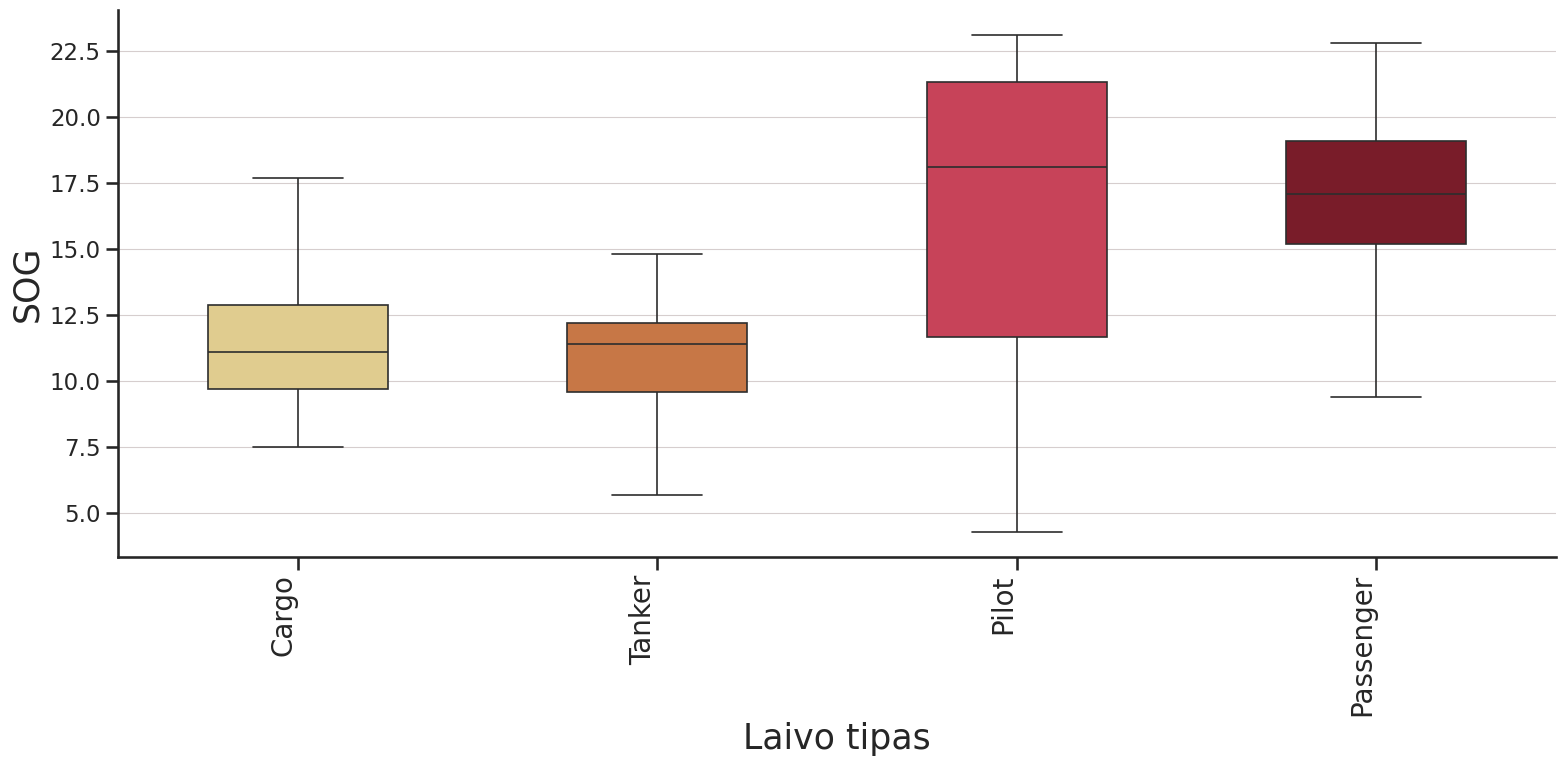

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_isskirciu = df_filtered[ df_filtered['ROT'] != 0 ]

def plot_box_by_shiptype(df, variables):
    
    dfp = df.dropna(subset=["Ship type"]).copy()
    dfp["Ship type"] = dfp["Ship type"].astype(str).str.strip()
    
    variables = [
        col for col in variables 
        if col in dfp.columns and pd.api.types.is_numeric_dtype(dfp[col])
    ]
    
    sns.set_theme(style="ticks", context="talk")

    ship_order = [
        "Cargo",
        "Tanker",
        "Pilot",
        "Passenger",
        "Fishing"
    ]

    color_map = {
        "Cargo": "#EDD382",
        "Tanker": "#DD7230",
        "Pilot": "#DD2D4A",
        "Passenger": "#880D1E",
        "Fishing": "#E56399",
    }  

    ship_order = [s for s in ship_order if s in dfp["Ship type"].unique()]

    for var in variables:
        
        plt.figure(figsize=(16, 8))
        
        valid_ship_types = [
            s for s in ship_order
            if s in dfp["Ship type"].unique()
            and dfp.loc[dfp["Ship type"] == s, var].notna().any()
        ]
        
        sns.boxplot(
        data=dfp,
        x="Ship type",
        y=var,
        order=valid_ship_types,
        palette=color_map,
        width=0.5,
        linewidth=1.2,
        showfliers=False
    )

        ax = plt.gca()
        ax.yaxis.grid(True, which='major', color="#D6CECEE7", linewidth=0.8)
        ax.xaxis.grid(False)

        plt.xticks(rotation=90, ha="right", fontsize=20)
        # plt.title(f"{var} pasiskirstymas pagal laivo tipą", fontsize=25, weight="bold")
        plt.xlabel("Laivo tipas", fontsize=25)
        plt.ylabel(var, fontsize=25)

        sns.despine()
        plt.tight_layout()
        plt.show()


plot_box_by_shiptype(df_isskirciu, ['SOG'])

/tmp/ipykernel_6835/1575044792.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


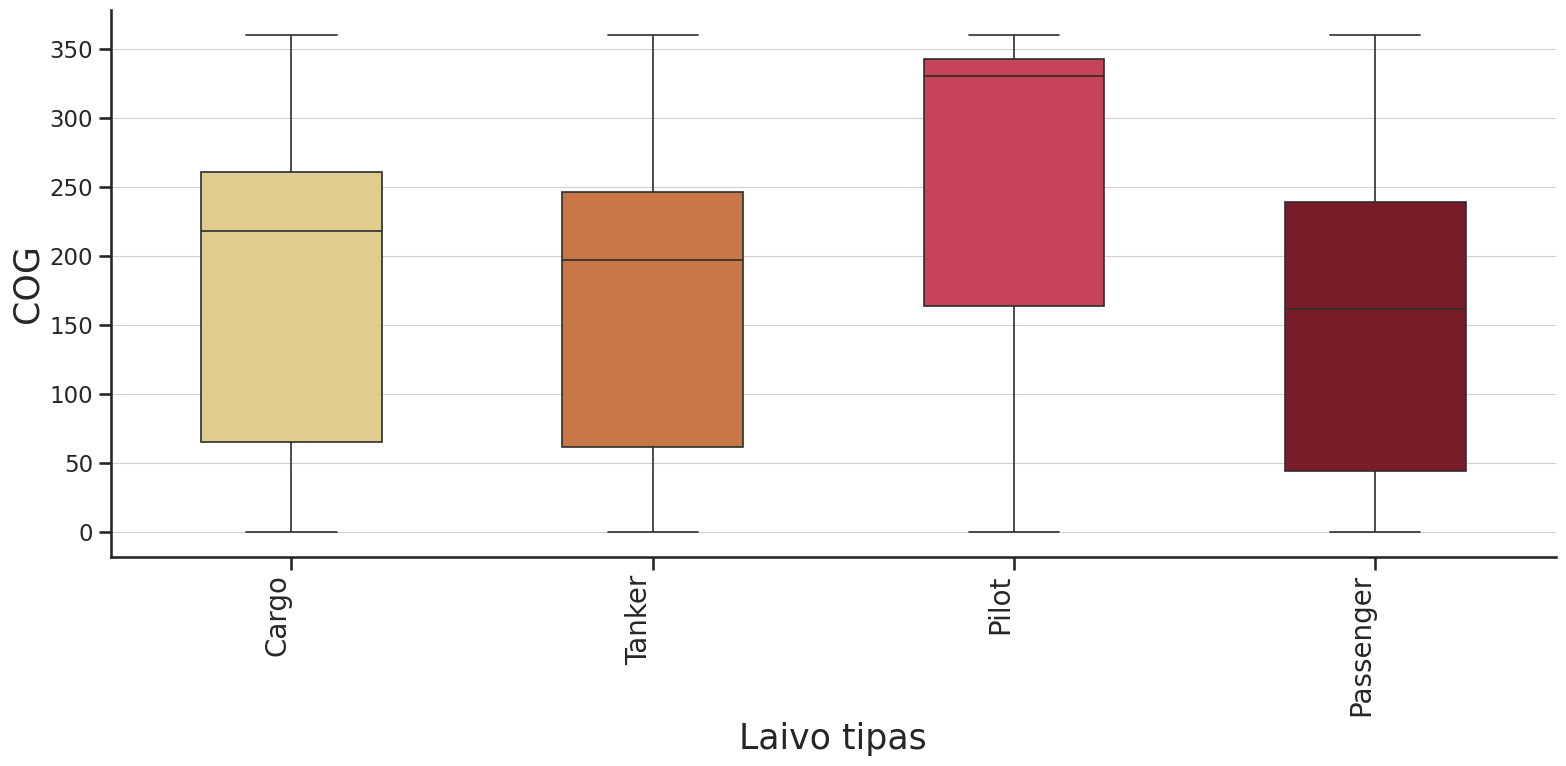

In [49]:
plot_box_by_shiptype(df_isskirciu, ['COG'])

/tmp/ipykernel_6835/1575044792.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


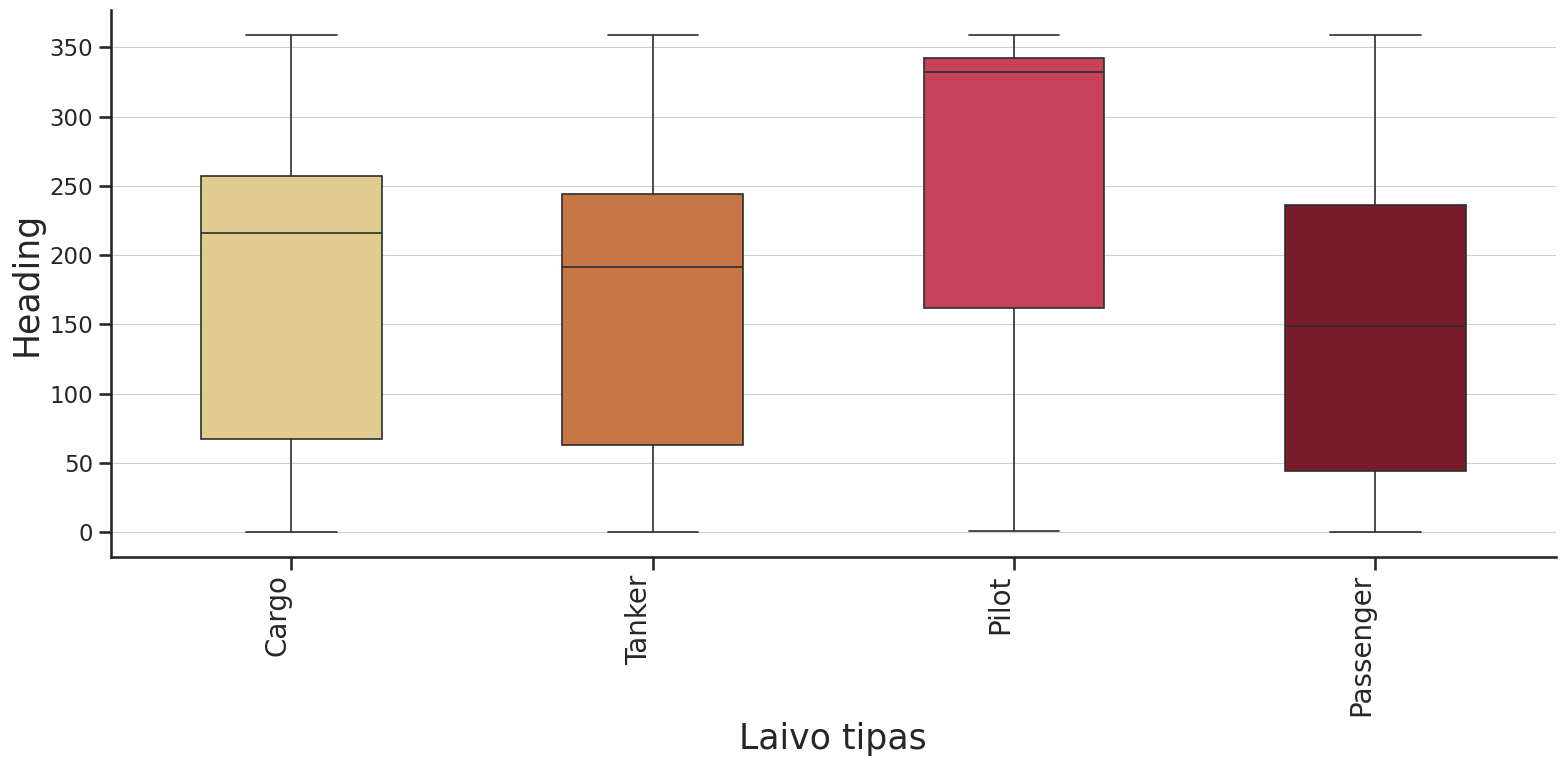

In [50]:
plot_box_by_shiptype(df_isskirciu, ['Heading'])

/tmp/ipykernel_6835/1575044792.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


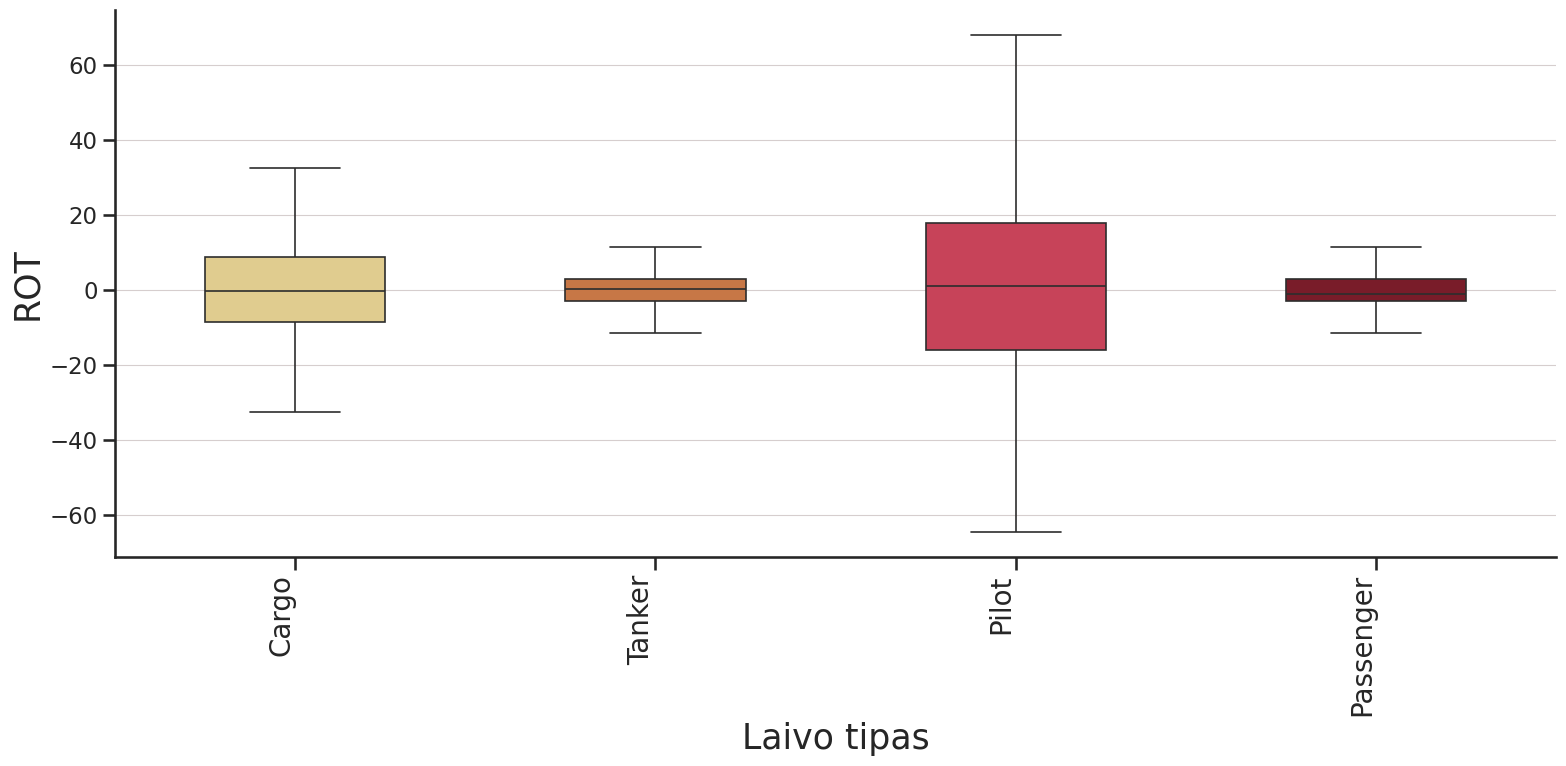

In [51]:
plot_box_by_shiptype(df_isskirciu, ['ROT'])

In [52]:
print( data[numerical].describe().drop(['count', 'mean', 'std']).T.to_latex() )

\begin{tabular}{lrrrrr}
\toprule
 & min & 25% & 50% & 75% & max \\
\midrule
Latitude & 0.000000 & 0.525753 & 0.672498 & 0.804742 & 1.000000 \\
Longitude & 0.000000 & 0.150298 & 0.271592 & 0.608874 & 1.000000 \\
ROT & 0.000000 & 0.482334 & 0.482334 & 0.482334 & 1.000000 \\
SOG & 0.000000 & 0.000000 & 0.273787 & 0.443598 & 1.000000 \\
Heading_sin & 0.000000 & 0.515038 & 0.819152 & 0.956305 & 1.000000 \\
Heading_cos & 0.000000 & 0.238450 & 0.586824 & 0.853553 & 1.000000 \\
COG_sin & 0.000000 & 0.436802 & 0.808656 & 0.947490 & 1.000000 \\
COG_cos & 0.000000 & 0.201615 & 0.506109 & 0.787466 & 1.000000 \\
delta_lon & 0.000000 & 0.000131 & 0.000766 & 0.041053 & 1.000000 \\
delta_lat & 0.000000 & 0.000311 & 0.002479 & 0.050954 & 1.000000 \\
\bottomrule
\end{tabular}



## Sekų formavimas

In [53]:
trajectories=[]
labels=[]

for mmsi, mmsi_data in data.groupby('MMSI'):

    sample = mmsi_data[[
        'Latitude',
        'Longitude',
        'ROT',
        'SOG',
        'Heading_sin',
        'Heading_cos',
        'COG_sin',
        'COG_cos',
        'delta_lat',
        'delta_lon'
    ]]
    ship_type = mmsi_data['Ship type'].values[0]

    sequences = np.empty( (sample.shape[0], 25, sample.shape[1]) )

    for ix, col in enumerate( sample.columns ):
        for lag in range( 25 ):
            sequences[:, lag, ix] = sample[col].shift(-1 * lag).T

    non_na_seq = sequences[:-25:25, :, :] 
    trajectories.append(non_na_seq)
    labels.extend( [ship_type] * non_na_seq.shape[0])

In [54]:
trajectories = np.concat( trajectories )

In [56]:
from sktime.distances import dtw_distance

In [57]:
np.unique( labels, return_counts=True)

(array(['Cargo', 'Fishing', 'Passenger', 'Pilot', 'Tanker'], dtype='<U9'),
 array([1055, 1174, 2426, 2354,  787]))

In [58]:
np.unique( np.array( labels ), return_counts=True )

(array(['Cargo', 'Fishing', 'Passenger', 'Pilot', 'Tanker'], dtype='<U9'),
 array([1055, 1174, 2426, 2354,  787]))

In [65]:
ships_indices = pd.DataFrame(data=labels, columns=['Type'])\
    .groupby('Type', group_keys=False)\
    .apply(lambda x: x.sample(150))\
    .reset_index()

indices = ships_indices['index'].tolist()

/tmp/ipykernel_6835/2129034038.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(150))\


In [66]:
trajectory_sample = trajectories[ indices ]

In [67]:
np.save('original_data.npy', trajectory_sample)

In [68]:
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from joblib import Parallel, delayed

In [69]:
def dtw_distance(i, j, series):
    dist, _ = fastdtw(series[i], series[j], dist=euclidean)
    return i, j, dist

def fastdtw_matrix(series, n_jobs=-1):
    n = len(series)
    matrix = np.zeros((n, n))

    pairs = [(i, j) for i in range(n) for j in range(i+1, n)]

    results = Parallel(n_jobs=n_jobs)(
        delayed(dtw_distance)(i, j, series) for i, j in pairs
    )

    for i, j, d in results:
        matrix[i, j] = d
        matrix[j, i] = d

    return matrix

In [70]:
dist_mat_dtw = fastdtw_matrix(trajectory_sample)

In [71]:
np.save('dist_mat.npy', dist_mat_dtw)
np.save('ship-types.npy', np.array(labels)[indices])

In [77]:
trajectory_sample.reshape((750,-1))

array([[2.58467429e-01, 5.57430667e-02, 4.82333724e-01, ...,
        2.92647276e-02, 5.30100578e-01, 6.85127907e-02],
       [3.28529087e-01, 3.86614225e-01, 2.86437569e-01, ...,
        3.40933948e-01, 8.27462222e-02, 1.18483129e-01],
       [1.28853108e-01, 2.46948481e-02, 4.82333724e-01, ...,
        9.45701183e-01, 1.83178660e-01, 3.88658186e-02],
       ...,
       [8.30417088e-01, 7.77611924e-01, 7.29608158e-01, ...,
        7.33579203e-01, 1.56049180e-01, 1.43899975e-01],
       [3.72290778e-01, 1.79917858e-01, 4.82333724e-01, ...,
        1.94927418e-01, 1.59564647e-01, 9.80157183e-02],
       [9.00447925e-01, 8.23487892e-01, 2.47633296e-01, ...,
        3.53409588e-01, 3.64036061e-04, 8.56477200e-05]], shape=(750, 250))

In [79]:
import scipy
dist_mat_euc = scipy.spatial.distance_matrix(
    trajectory_sample.reshape((750, -1)),
    trajectory_sample.reshape((750, -1))
)

In [80]:
np.save('dist_mat_euc.npy', dist_mat_euc)